# Inception FID on Random Test Subset

Ноутбук делает такой evaluation protocol:
- случайно выбирает `1000` `.npy` полей из `test`
- генерирует `1000` fake samples для тех же кейсов через `concat` sampler
- считает `Inception-FID` между real и fake
- повторяет расчёт для двух разных `RGB` colormap-конфигураций


In [1]:
import glob
import json
import os
import platform
import shutil
from pathlib import Path
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers.models.unets.unet_2d import UNet2DModel
from diffusers.training_utils import EMAModel

from concat.sampler import Sampler
from fid.inception_fid import (
    InceptionFeatureExtractor,
    RenderConfig,
    compute_feature_stats_for_folder,
    compute_frechet_distance,
    default_data_root,
    default_inception_weights_path,
    default_stats_json_path,
    load_channel_stats,
    render_field_to_rgb,
)
from utils import (
    NpyImageDataset,
    channel_denormalize,
    channel_normalize,
    generate_satellite_track_mask,
    get_device,
)

if platform.system() == 'Darwin':
    REPO_DIR = '/Users/amir/sciml/diffusion_data_assimilation'
else:
    REPO_DIR = os.getcwd()

os.chdir(REPO_DIR)

IMAGE_SIZE = (320, 256)
DATA_ROOT = default_data_root()
TEST_DIR = os.path.join(DATA_ROOT, 'test')
STATS_JSON = default_stats_json_path(DATA_ROOT)
MASK_PATH = os.path.join(DATA_ROOT, 'mask_padding.npy')

CHECKPOINT_DIR = os.path.join(REPO_DIR, 'checkpoints')
CHECKPOINT_NAME = 'ema_best_model.pth'
CONCAT_RUN_DIR = None

DEVICE = get_device()
WEIGHTS_PATH = default_inception_weights_path(REPO_DIR)
BATCH_SIZE_GENERATE = 4
BATCH_SIZE_FID = 16
NUM_WORKERS = 0
NUM_TIMESTEPS = 10
METHOD = 'dopri5'
N_TRACKS_RANGE = (0, 0)
N_SAMPLES = 1000
SELECTION_SEED = 1234
GENERATION_SEED = 1234
RESIZE_TO = 299

WORK_DIR = '/tmp/inception_fid_test_eval'
REAL_SUBSET_DIR = os.path.join(WORK_DIR, 'real_test_subset')
FAKE_SUBSET_DIR = os.path.join(WORK_DIR, 'fake_test_subset_concat')
CLEAR_OUTPUT_DIRS = True

RENDER_EXPERIMENTS = [
    {
        'name': 'channel0_viridis',
        'mode': 'channel0',
        'channel0_cmap': 'viridis',
        'channel0_vmin': 0.0,
        'channel0_vmax': 1.0,
        'channel1_cmap': 'magma',
        'channel1_vmin': 0.0,
        'channel1_vmax': 1.0,
        'blend_alpha': 0.5,
    },
    {
        'name': 'channel0_plasma',
        'mode': 'channel0',
        'channel0_cmap': 'plasma',
        'channel0_vmin': 0.0,
        'channel0_vmax': 1.0,
        'channel1_cmap': 'magma',
        'channel1_vmin': 0.0,
        'channel1_vmax': 1.0,
        'blend_alpha': 0.5,
    },
]

print('repo_dir         =', REPO_DIR)
print('test_dir         =', TEST_DIR)
print('work_dir         =', WORK_DIR)
print('device           =', DEVICE)
print('weights_path     =', WEIGHTS_PATH)
print('n_samples        =', N_SAMPLES)
print('num_timesteps    =', NUM_TIMESTEPS)
print('method           =', METHOD)
print('n_tracks_range   =', N_TRACKS_RANGE)
print('render configs   =', [cfg['name'] for cfg in RENDER_EXPERIMENTS])


repo_dir         = /home
test_dir         = /mnt/sciml/a.sadreev/sea_ice_data/test
work_dir         = /tmp/inception_fid_test_eval
device           = cuda
weights_path     = None
n_samples        = 1000
num_timesteps    = 10
method           = dopri5
n_tracks_range   = (0, 0)
render configs   = ['channel0_viridis', 'channel0_plasma']


In [2]:
with open(STATS_JSON) as f:
    stats = json.load(f)
CHANNEL_MEAN = tuple(stats['mean'])
CHANNEL_STD = tuple(stats['std'])
VALID_MASK = np.load(MASK_PATH).astype(np.float32)

all_test_files = sorted([p.name for p in Path(TEST_DIR).glob('*.npy')])
assert len(all_test_files) >= N_SAMPLES, f'Need at least {N_SAMPLES} test files, got {len(all_test_files)}'

rng = np.random.default_rng(SELECTION_SEED)
selected_files = sorted(rng.choice(all_test_files, size=N_SAMPLES, replace=False).tolist())

if CLEAR_OUTPUT_DIRS:
    shutil.rmtree(REAL_SUBSET_DIR, ignore_errors=True)
    shutil.rmtree(FAKE_SUBSET_DIR, ignore_errors=True)

os.makedirs(REAL_SUBSET_DIR, exist_ok=True)
os.makedirs(FAKE_SUBSET_DIR, exist_ok=True)

for name in selected_files:
    src = os.path.join(TEST_DIR, name)
    dst = os.path.join(REAL_SUBSET_DIR, name)
    if os.path.lexists(dst):
        os.remove(dst)
    os.symlink(src, dst)

print('selected_files   =', len(selected_files))
print('first 5          =', selected_files[:5])
print('real_subset_dir  =', REAL_SUBSET_DIR)


selected_files   = 1000
first 5          = ['ocean+atmosphere_24_2023-01-01_processed000.npy', 'ocean+atmosphere_24_2023-01-01_processed016.npy', 'ocean+atmosphere_24_2023-01-02_processed000.npy', 'ocean+atmosphere_24_2023-01-02_processed003.npy', 'ocean+atmosphere_24_2023-01-02_processed008.npy']
real_subset_dir  = /tmp/inception_fid_test_eval/real_test_subset


In [3]:
if CONCAT_RUN_DIR is None:
    candidates = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, '**', CHECKPOINT_NAME), recursive=True))
    assert candidates, f'No {CHECKPOINT_NAME} found under {CHECKPOINT_DIR}'
    CONCAT_RUN_DIR = os.path.dirname(candidates[-1])

print('concat_run_dir =', CONCAT_RUN_DIR)

model = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=7,
    out_channels=2,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512, 512),
    down_block_types=(
        'DownBlock2D', 'DownBlock2D', 'DownBlock2D',
        'AttnDownBlock2D', 'DownBlock2D',
    ),
    up_block_types=(
        'UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D',
        'UpBlock2D', 'UpBlock2D',
    ),
)

checkpoint_path = os.path.join(CONCAT_RUN_DIR, CHECKPOINT_NAME)
ema = EMAModel(model.parameters(), decay=0.999)
try:
    ema_state = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
except TypeError:
    ema_state = torch.load(checkpoint_path, map_location='cpu')
ema.load_state_dict(ema_state)
ema.copy_to(model.parameters())
model.eval().to(DEVICE)

sampler = Sampler(model)
print('model loaded from', checkpoint_path)


concat_run_dir = /home/checkpoints/run_20260305_230016
model loaded from /home/checkpoints/run_20260305_230016/ema_best_model.pth


In [4]:
transform = partial(channel_normalize, channel_mean=CHANNEL_MEAN, channel_std=CHANNEL_STD)
test_dataset = NpyImageDataset(
    folder=TEST_DIR,
    file_list=selected_files,
    transform=transform,
    preload=False,
    mmap_mode='r',
)

torch.manual_seed(GENERATION_SEED)
np.random.seed(GENERATION_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GENERATION_SEED)

num_exported = 0
for batch_start in range(0, len(test_dataset), BATCH_SIZE_GENERATE):
    batch_files = selected_files[batch_start:batch_start + BATCH_SIZE_GENERATE]
    clean_batch = torch.stack([test_dataset[batch_start + i] for i in range(len(batch_files))]).to(DEVICE)
    bs = clean_batch.shape[0]

    mask_np = generate_satellite_track_mask(
        image_size=IMAGE_SIZE,
        batch_size=bs,
        valid_mask=VALID_MASK,
        n_tracks_range=N_TRACKS_RANGE,
    )
    mask = torch.from_numpy(mask_np).unsqueeze(1).to(device=DEVICE, dtype=clean_batch.dtype)
    observed = clean_batch * mask

    samples = sampler.sample_conditioned(
        mask=mask,
        observed=observed,
        size=IMAGE_SIZE,
        num_timesteps=NUM_TIMESTEPS,
        device=DEVICE,
        method=METHOD,
    )
    samples = channel_denormalize(samples.detach().cpu(), CHANNEL_MEAN, CHANNEL_STD)

    for sample, name in zip(samples, batch_files):
        np.save(os.path.join(FAKE_SUBSET_DIR, name), sample.numpy().astype(np.float32))
        num_exported += 1

print('fake_subset_dir =', FAKE_SUBSET_DIR)
print('num_exported    =', num_exported)


fake_subset_dir = /tmp/inception_fid_test_eval/fake_test_subset_concat
num_exported    = 1000


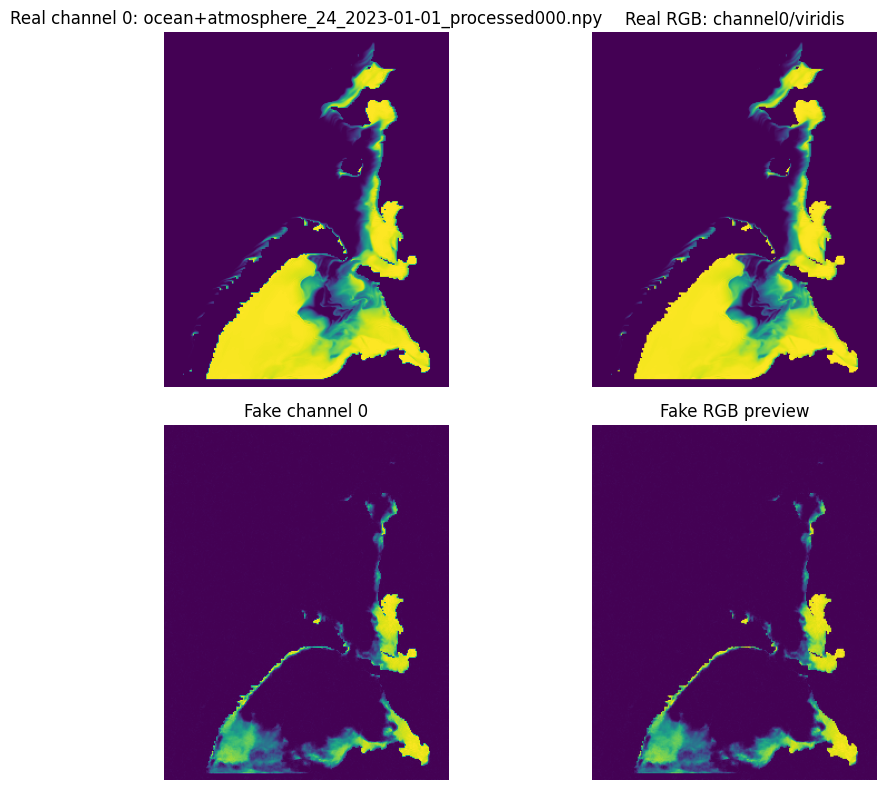

In [7]:
sample_name = selected_files[0]
real_sample = np.load(os.path.join(REAL_SUBSET_DIR, sample_name)).astype(np.float32)
fake_sample = np.load(os.path.join(FAKE_SUBSET_DIR, sample_name)).astype(np.float32)

preview_cfg_dict = {k: v for k, v in RENDER_EXPERIMENTS[0].items() if k != 'name'}
preview_cfg = RenderConfig(
    **preview_cfg_dict,
    input_normalized=False,
    channel_mean=None,
    channel_std=None,
)

real_rgb = render_field_to_rgb(real_sample, preview_cfg)
fake_rgb = render_field_to_rgb(fake_sample, preview_cfg)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(real_sample[0], cmap='viridis', vmin=0.0, vmax=1.0)
axes[0, 0].set_title(f'Real channel 0: {sample_name}')
axes[0, 0].axis('off')
axes[0, 1].imshow(np.moveaxis(real_rgb, 0, -1))
axes[0, 1].set_title(f'Real RGB: {preview_cfg.mode}/{preview_cfg.channel0_cmap}')
axes[0, 1].axis('off')
axes[1, 0].imshow(fake_sample[0], cmap='viridis', vmin=0.0, vmax=1.0)
axes[1, 0].set_title('Fake channel 0')
axes[1, 0].axis('off')
axes[1, 1].imshow(np.moveaxis(fake_rgb, 0, -1))
axes[1, 1].set_title('Fake RGB preview')
axes[1, 1].axis('off')
plt.tight_layout()


In [10]:
from fid.inception_fid import _import_torchvision_inception, default_device, _safe_torch_load
import torch
import torch.nn as nn
import torch.nn.functional as F

class InceptionFeatureExtractor(nn.Module):
    def __init__(self, device=None, resize_to=299, weights_path=None):
        super().__init__()
        inception_v3, Inception_V3_Weights = _import_torchvision_inception()

        self.device_name = str(device or default_device())
        self.resize_to = int(resize_to)
        if self.resize_to <= 0:
            raise ValueError(f"resize_to must be positive, got {self.resize_to}")

        if weights_path:
            model = inception_v3(weights=None, aux_logits=False, transform_input=False)
            model.load_state_dict(_safe_torch_load(weights_path))
        else:
            model = inception_v3(
                weights=Inception_V3_Weights.DEFAULT,
                aux_logits=True,
                transform_input=False,
            )
            model.AuxLogits = None

        model.fc = nn.Identity()
        model.eval().to(self.device_name)
        self.model = model

        self.register_buffer(
            "image_mean",
            torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1),
            persistent=False,
        )
        self.register_buffer(
            "image_std",
            torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1),
            persistent=False,
        )

    def forward(self, x):
        if x.ndim != 4 or x.shape[1] != 3:
            raise ValueError(f"Expected input of shape [B, 3, H, W], got {tuple(x.shape)}")
        x = x.to(self.device_name, dtype=torch.float32)
        x = F.interpolate(
            x, size=(self.resize_to, self.resize_to), mode="bilinear", align_corners=False
        )
        x = (x - self.image_mean) / self.image_std
        return self.model(x)


In [14]:
extractor = InceptionFeatureExtractor(
    device=DEVICE,
    resize_to=RESIZE_TO,
    weights_path=WEIGHTS_PATH,
)
print('extractor device =', extractor.device_name)


extractor.image_mean = extractor.image_mean.to(extractor.device_name)
extractor.image_std = extractor.image_std.to(extractor.device_name)



extractor device = cuda


In [15]:
print("WEIGHTS_PATH =", WEIGHTS_PATH)
print("exists =", os.path.exists(WEIGHTS_PATH) if WEIGHTS_PATH else None)


WEIGHTS_PATH = None
exists = None


In [16]:
results = []

for cfg_dict in RENDER_EXPERIMENTS:
    render_kwargs = {k: v for k, v in cfg_dict.items() if k != 'name'}
    render_config = RenderConfig(
        **render_kwargs,
        input_normalized=False,
        channel_mean=None,
        channel_std=None,
    )


    real_stats = compute_feature_stats_for_folder(
        folder=REAL_SUBSET_DIR,
        extractor=extractor,
        render_config=render_config,
        batch_size=BATCH_SIZE_FID,
        num_workers=NUM_WORKERS,
        max_items=None,
        desc=f"real features: {cfg_dict['name']}",
    )
    fake_stats = compute_feature_stats_for_folder(
        folder=FAKE_SUBSET_DIR,
        extractor=extractor,
        render_config=render_config,
        batch_size=BATCH_SIZE_FID,
        num_workers=NUM_WORKERS,
        max_items=None,
        desc=f"fake features: {cfg_dict['name']}",
    )
    fid_score = compute_frechet_distance(real_stats, fake_stats)

    results.append({
        'name': cfg_dict['name'],
        'fid': float(fid_score),
        'real_count': int(real_stats.count),
        'fake_count': int(fake_stats.count),
        'feature_dim': int(real_stats.feature_dim),
        'render_config': render_config.__dict__,
    })

print(json.dumps(results, indent=2))


real features: channel0_viridis:   0%|          | 0/63 [00:00<?, ?it/s]

fake features: channel0_viridis:   0%|          | 0/63 [00:00<?, ?it/s]

real features: channel0_plasma:   0%|          | 0/63 [00:00<?, ?it/s]

fake features: channel0_plasma:   0%|          | 0/63 [00:00<?, ?it/s]

[
  {
    "name": "channel0_viridis",
    "fid": 87.59303199775226,
    "real_count": 1000,
    "fake_count": 1000,
    "feature_dim": 2048,
    "render_config": {
      "mode": "channel0",
      "channel0_cmap": "viridis",
      "channel1_cmap": "magma",
      "channel0_vmin": 0.0,
      "channel0_vmax": 1.0,
      "channel1_vmin": 0.0,
      "channel1_vmax": 1.0,
      "blend_alpha": 0.5,
      "input_normalized": false,
      "channel_mean": null,
      "channel_std": null
    }
  },
  {
    "name": "channel0_plasma",
    "fid": 87.32778812572778,
    "real_count": 1000,
    "fake_count": 1000,
    "feature_dim": 2048,
    "render_config": {
      "mode": "channel0",
      "channel0_cmap": "plasma",
      "channel1_cmap": "magma",
      "channel0_vmin": 0.0,
      "channel0_vmax": 1.0,
      "channel1_vmin": 0.0,
      "channel1_vmax": 1.0,
      "blend_alpha": 0.5,
      "input_normalized": false,
      "channel_mean": null,
      "channel_std": null
    }
  }
]


In [17]:
for row in results:
    print(f"{row['name']}: FID={row['fid']:.6f} | real={row['real_count']} | fake={row['fake_count']}")


channel0_viridis: FID=87.593032 | real=1000 | fake=1000
channel0_plasma: FID=87.327788 | real=1000 | fake=1000


In [18]:
import os
import shutil

# Текущие директории, где уже лежат результаты этого запуска
CURRENT_REAL_SUBSET_DIR = REAL_SUBSET_DIR
CURRENT_FAKE_SUBSET_DIR = FAKE_SUBSET_DIR

# Постоянная директория рядом с train/test
PERSISTENT_WORK_DIR = os.path.join(DATA_ROOT, "inception_fid_test_eval")
PERSISTENT_REAL_SUBSET_DIR = os.path.join(PERSISTENT_WORK_DIR, "real_test_subset")
PERSISTENT_FAKE_SUBSET_DIR = os.path.join(PERSISTENT_WORK_DIR, "fake_test_subset_concat")

os.makedirs(PERSISTENT_REAL_SUBSET_DIR, exist_ok=True)
os.makedirs(PERSISTENT_FAKE_SUBSET_DIR, exist_ok=True)

real_saved = 0
fake_saved = 0

for name in sorted(os.listdir(CURRENT_REAL_SUBSET_DIR)):
    src = os.path.join(CURRENT_REAL_SUBSET_DIR, name)
    dst = os.path.join(PERSISTENT_REAL_SUBSET_DIR, name)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        real_saved += 1

for name in sorted(os.listdir(CURRENT_FAKE_SUBSET_DIR)):
    src = os.path.join(CURRENT_FAKE_SUBSET_DIR, name)
    dst = os.path.join(PERSISTENT_FAKE_SUBSET_DIR, name)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        fake_saved += 1

print("saved real to :", PERSISTENT_REAL_SUBSET_DIR)
print("saved fake to :", PERSISTENT_FAKE_SUBSET_DIR)


KeyboardInterrupt: 

In [21]:
import os
import numpy as np
import torch

fake_files = sorted([f for f in os.listdir(FAKE_SUBSET_DIR) if f.endswith(".npy")])
print("num fake files =", len(fake_files))

sample_path = os.path.join(FAKE_SUBSET_DIR, fake_files[100])
fake_arr = np.load(sample_path).astype(np.float32)
fake_tensor = torch.from_numpy(fake_arr)

print("file =", fake_files[0])
print("shape =", fake_tensor.shape)
print("dtype =", fake_tensor.dtype)
print("device =", fake_tensor.device)


num fake files = 1000
file = ocean+atmosphere_24_2023-01-01_processed000.npy
shape = torch.Size([2, 320, 256])
dtype = torch.float32
device = cpu


In [22]:
import os
import shutil

SRC_DIR = FAKE_SUBSET_DIR
DST_DIR = "/mnt/sciml/a.sadreev/sea_ice_data/inception_fid_test_eval/fake_test_subset_concat"

os.makedirs(DST_DIR, exist_ok=True)

saved = 0
for name in sorted(os.listdir(SRC_DIR)):
    src = os.path.join(SRC_DIR, name)
    dst = os.path.join(DST_DIR, name)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        saved += 1

print("source      =", SRC_DIR)
print("destination =", DST_DIR)
print("saved       =", saved)
print("total dst   =", len(os.listdir(DST_DIR)))


source      = /tmp/inception_fid_test_eval/fake_test_subset_concat
destination = /mnt/sciml/a.sadreev/sea_ice_data/inception_fid_test_eval/fake_test_subset_concat
saved       = 1000
total dst   = 1000
